# Técnicas de balanceo combinadas en series CGM para predicción de glucosa

**TFM — Predicción continua de glucosa en pacientes con diabetes tipo 1**  
**Fecha:** Junio 2026

---

## 1. Introducción y motivación

Este notebook implementa y evalúa cinco estrategias híbridas de balanceo para series temporales de glucosa continua (CGM). Su punto de partida son los resultados obtenidos en `00_Balancing_Techniques.ipynb`, donde se evaluaron ocho técnicas individuales sobre catorce escenarios experimentales derivados de los datasets DIATREND, REPLACE-BG y T1DiabetesGranada.

### 1.1 Marco conceptual: balanceo orientado a predicción, no a clasificación

Un aspecto crítico que distingue este trabajo de la literatura clásica de *imbalanced learning* es que el objetivo final **no es clasificar correctamente la etiqueta glucémica** (hipoglucemia, normoglucemia, hiperglucemia), sino **predecir con mayor precisión el valor continuo de glucosa en los horizontes temporales futuros** (típicamente 30, 60 y 120 minutos).

Esta distinción tiene implicaciones metodológicas profundas:

1. **El desbalanceo no deteriora directamente la exactitud global del clasificador**, sino que deteriora la capacidad del modelo regresor para aprender las dinámicas glucémicas asociadas a rangos infrarrepresentados. Cuando la hipoglucemia representa menos del 2% de las muestras de entrenamiento, el modelo aprende insuficientemente los patrones de descenso rápido que preceden a un evento hipoglucémico, lo cual se manifiesta en un aumento del MAE y del RMSE en la zona subglucémica (<70 mg/dL) sin que la pérdida global sea apreciablemente peor.

2. **Las métricas de evaluación relevantes son las de regresión zonificada**: MAE-hypo (error en zona hipoglucémica), MAE-hyper (error en zona hiperglucémica), RMSE total, y —específicamente en CGM— la tasa de predicciones en Zona A de la Clarke Error Grid (CEG-A), que cuantifica la fracción de predicciones clínicamente aceptables.

3. **El balanceo tiene efecto indirecto sobre la regresión**: al aumentar artificialmente la representación de episodios hipoglucémicos en el conjunto de entrenamiento, el modelo recibe más ejemplos de las dinámicas que preceden y suceden a los eventos críticos, lo que mejora su capacidad de interpolación en esas regiones del espacio glucémico.

### 1.2 Resultados previos y brecha identificada

El análisis de técnicas individuales reveló una **brecha estructural** que ninguna técnica por sí sola cierra simultáneamente:

| Técnica | Mejora de balance | Preservación fisiológica | Robustez ante pool pequeño |
|---|---|---|---|
| ROS episódico (T1) | Moderada (+10%) | Excelente (RoC ~4%) | Baja |
| SMOTE temporal (T4) | Alta (+14-24%) | Aceptable (RoC ~7%) | Media |
| Cost-sensitive (T3) | Indirecta | Perfecta | Alta |
| Episode-aware (T7) | Nula/marginal | Excelente | Alta |
| Patient-level (T6) | Nula/marginal | Excelente | Alta |

Esta estructura de fallos **parcialmente ortogonales** es precisamente lo que hace viable y esperanzador el enfoque híbrido: cuando dos métodos fallan por razones distintas, su combinación tiene posibilidad de cancelar los sesgos respectivos. Este principio, bien documentado en la literatura de ensemble learning, constituye la base teórica de las cinco combinaciones propuestas.

### 1.3 Combinaciones implementadas

| ID | Nombre | Técnicas involucradas | Dataset óptimo |
|---|---|---|---|
| **H1** | RUS-antes-de-SMOTE | T2 → T4 | REPLACE-BG, T1DiabetesGranada |
| **H2** | Patient-Level-ROS + SMOTE selectivo | T6(T1) + T4 intra-paciente | DIATREND |
| **H3** | SMOTE temporal + Cost-Sensitive en cascada | T4 → T3 | Los tres datasets |
| **H4** | Segmentación-primero + ROS intra-sub-serie | Sub-serie → T6(T1) | T1DiabetesGranada |
| **H5** | Estratificación demográfica + oversampling intra-estrato | Estrato → T1/T4 | REPLACE-BG |


---

## 2. Setup y carga de experimentos

Se reutiliza el pipeline de carga y evaluación definido en `00_Balancing_Techniques.ipynb`. La estructura de columnas (`patient_id`, `timestamp`, `glucose`, `class_label`, `episode_id`, `segment_id`, `freq_min`, `dataset`) se mantiene consistente con el resto del proyecto. Se añaden únicamente las funciones necesarias para las combinaciones híbridas.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ─── Semilla de reproducibilidad ───────────────────────────────────────────
SEED = 42
rng = np.random.default_rng(SEED)

# ─── Directorio de experimentos (mismo que en Balancing_Techniques) ────────
def locate_experiments_dir() -> Path:
    paths = [
        Path('data/processed/experiments'),
        Path('../04_Experiments/data/processed/experiments'),
        Path('../../data/processed/experiments'),
        Path('notebooks/04_Experiments/data/processed/experiments')
    ]
    for p in paths:
        if p.exists() and any(p.glob('*.parquet')):
            return p
    raise FileNotFoundError('No se pudo encontrar el directorio de experimentos (.parquet).')

exp_dir = locate_experiments_dir()
print(f'Directorio de experimentos detectado: {exp_dir.resolve()}')

# ─── Directorio de resultados ───────────────────────────────────────────────
results_dir = Path('results')
tables_dir  = results_dir / 'tables'
figures_dir = results_dir / 'figures'
for d in [tables_dir, figures_dir]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Directorio de resultados: {results_dir.resolve()}')

Directorio de experimentos detectado: C:\Users\User\Desktop\TFM-Glucose-Prediction\notebooks\04_Experiments\data\processed\experiments
Directorio de resultados: C:\Users\User\Desktop\TFM-Glucose-Prediction\notebooks\03_Balancing_Techniques\results


### 2.1 Funciones auxiliares reutilizadas

Se reproducen las funciones de carga, evaluación temporal y resumen de dataset tal como fueron definidas en `00_Balancing_Techniques.ipynb`, garantizando consistencia total con los resultados previos. No se introducen modificaciones.


In [2]:
# ──────────────────────────────────────────────────────────────────────────────
# FUNCIONES DE CARGA Y EVALUACIÓN
# Reproducidas íntegramente de 00_Balancing_Techniques.ipynb
# ──────────────────────────────────────────────────────────────────────────────

def load_experiment(name: str) -> pd.DataFrame:
    """Carga un experimento .parquet del directorio de experimentos."""
    path = exp_dir / f'{name}.parquet'
    if not path.exists():
        raise FileNotFoundError(f'No existe el experimento: {name}')
    df = pd.read_parquet(path)
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    return df


def compute_autocorr(df: pd.DataFrame, lag: int = 1) -> float:
    """Calcula la autocorrelación media lag-1 de la glucosa por paciente."""
    corrs = []
    for _, group in df.groupby('patient_id', sort=False):
        g = group.sort_values('timestamp')
        if len(g) > lag:
            c = g['glucose'].autocorr(lag=lag)
            if not pd.isna(c):
                corrs.append(c)
    return float(np.mean(corrs)) if corrs else float('nan')


def check_roc_violations(
    df: pd.DataFrame,
    freq_min: int = 5,
    roc_threshold: float = 3.0
) -> tuple[int, float]:
    """
    Cuenta violaciones de la tasa de cambio fisiológicamente plausible.
    Solo evalúa pasos consecutivos dentro del intervalo nominal (≤ freq_min×1.5 min).
    """
    total_violations = 0
    total_valid = 0
    for _, group in df.groupby('patient_id', sort=False):
        g = group.sort_values('timestamp')
        dt = g['timestamp'].diff().dt.total_seconds().div(60)
        dg = g['glucose'].diff().abs()
        roc = dg / dt
        valid = (dt > 0) & (dt <= freq_min * 1.5)
        valid_roc = roc[valid]
        total_violations += int((valid_roc > roc_threshold).sum())
        total_valid += int(valid_roc.shape[0])
    pct = (total_violations / total_valid * 100) if total_valid > 0 else 0.0
    return total_violations, pct


def summarize_dataset(df: pd.DataFrame, label: str) -> pd.DataFrame:
    """
    Genera un resumen con las métricas de evaluación clave:
    distribución de clases, autocorrelación y violaciones de RoC.
    """
    counts = df['class_label'].value_counts(normalize=True) * 100
    freq_min = int(df['freq_min'].iloc[0]) if 'freq_min' in df.columns else 5
    autocorr = compute_autocorr(df)
    viols, pct = check_roc_violations(df, freq_min=freq_min)
    out = pd.DataFrame({
        'metric': ['n_rows', 'n_patients', 'pct_hypo', 'pct_normo',
                   'pct_hyper', 'autocorr_lag1', 'roc_violations', 'roc_pct'],
        'value': [
            len(df),
            df['patient_id'].nunique(),
            float(counts.get('hypoglycemia', 0.0)),
            float(counts.get('normoglycemia', 0.0)),
            float(counts.get('hyperglycemia', 0.0)),
            float(autocorr),
            int(viols),
            float(pct)
        ]
    })
    out['dataset'] = label
    return out


print('Funciones auxiliares cargadas correctamente.')

Funciones auxiliares cargadas correctamente.


### 2.2 Funciones de técnicas individuales

Las implementaciones de T1–T8 se reproducen directamente de `00_Balancing_Techniques.ipynb` sin modificación. Las combinaciones híbridas las invocan como componentes modulares.


In [3]:
# ──────────────────────────────────────────────────────────────────────────────
# T1 — Random Oversampling episódico
# ──────────────────────────────────────────────────────────────────────────────
def ros_episode(
    df: pd.DataFrame,
    target_ratio: float,
    seed: int
) -> pd.DataFrame:
    """
    Duplica episodios hipoglucémicos completos hasta alcanzar el target_ratio.
    La unidad de remuestreo es el episodio clínico, no el punto individual.
    Los episodios duplicados se añaden con timestamps continuos al final de la serie.
    """
    rng_local = np.random.default_rng(seed)
    out = []
    for pid, g in df.groupby('patient_id', sort=False):
        g = g.sort_values('timestamp').reset_index(drop=True)
        n_min   = int((g['class_label'] == 'hypoglycemia').sum())
        n_total = len(g)
        n_other = n_total - n_min
        if n_other <= 0:
            out.append(g)
            continue
        n_target = int((target_ratio * n_other) / (1 - target_ratio))
        if n_target <= n_min:
            out.append(g)
            continue
        episodes   = g[g['class_label'] == 'hypoglycemia'].groupby('episode_id', sort=False)
        episode_list = [ep for _, ep in episodes]
        if not episode_list:
            out.append(g)
            continue
        needed = n_target - n_min
        added_blocks = []
        count = 0
        idx   = 0
        while count < needed:
            ep = episode_list[rng_local.integers(0, len(episode_list))]
            b  = ep.copy().reset_index(drop=True)
            b['episode_id'] = f'{pid}_synth_ros_{idx}'
            added_blocks.append(b)
            count += len(b)
            idx   += 1
        dup = pd.concat(added_blocks, ignore_index=True)
        freq_min  = int(g['freq_min'].iloc[0]) if 'freq_min' in g.columns else 5
        base_time = g['timestamp'].max() + pd.Timedelta(minutes=freq_min)
        dup['timestamp']  = pd.date_range(base_time, periods=len(dup), freq=f'{freq_min}min')
        dup['segment_id'] = f'{pid}_synth'
        out.append(pd.concat([g, dup], ignore_index=True))
    return pd.concat(out, ignore_index=True)


# ──────────────────────────────────────────────────────────────────────────────
# T2 — Random Undersampling temporal con preservación de contexto
# ──────────────────────────────────────────────────────────────────────────────
def rus_temporal(
    df: pd.DataFrame,
    context_steps: int,
    keep_ratio: float,
    seed: int
) -> pd.DataFrame:
    """
    Reduce la clase mayoritaria eliminando puntos de normoglucemia estable.
    Preserva una ventana de context_steps alrededor de cada evento hipo/hiper.
    Sólo elimina puntos 'distant' (alejados de transiciones clínicas).
    """
    rng_local = np.random.default_rng(seed)
    out = []
    for pid, g in df.groupby('patient_id', sort=False):
        g = g.sort_values('timestamp').reset_index(drop=True)
        interest = g['class_label'].isin(['hypoglycemia', 'hyperglycemia']).values
        context  = interest.copy()
        n = len(g)
        for i in range(n):
            if interest[i]:
                start = max(0, i - context_steps)
                end   = min(n, i + context_steps + 1)
                context[start:end] = True
        distant = np.where(~context)[0]
        if len(distant) == 0:
            out.append(g)
            continue
        n_keep   = int(len(distant) * keep_ratio)
        keep_idx = rng_local.choice(distant, size=n_keep, replace=False) if n_keep > 0 else np.array([], dtype=int)
        keep_mask = np.zeros(n, dtype=bool)
        keep_mask[context]  = True
        keep_mask[keep_idx] = True
        out.append(g[keep_mask])
    return pd.concat(out, ignore_index=True)


# ──────────────────────────────────────────────────────────────────────────────
# T3 — Cost-sensitive learning
# ──────────────────────────────────────────────────────────────────────────────
def compute_class_weights(df: pd.DataFrame) -> dict:
    """
    Calcula pesos de clase inversamente proporcionales a la frecuencia.
    Pesos = total / (n_classes × count_clase).
    No modifica el dataset; los pesos se pasan al optimizador o función de pérdida.
    """
    counts    = df['class_label'].value_counts()
    total     = len(df)
    n_classes = len(counts)
    weights   = {cls: total / (n_classes * count) for cls, count in counts.items()}
    return weights


# ──────────────────────────────────────────────────────────────────────────────
# T4 — SMOTE adaptado temporalmente
# ──────────────────────────────────────────────────────────────────────────────
def smote_temporal(
    df: pd.DataFrame,
    window_size: int,
    target_ratio: float,
    max_gap_steps: int,
    seed: int
) -> pd.DataFrame:
    """
    Genera ventanas hipoglucémicas sintéticas interpolando entre pares de ventanas
    reales dentro del mismo paciente y segmento temporal.
    Respeta gaps: solo interpola entre vecinos sin cruzar fragmentos discontinuos.
    """
    rng_local = np.random.default_rng(seed)
    out = []
    for pid, g in df.groupby('patient_id', sort=False):
        g = g.sort_values('timestamp').reset_index(drop=True)
        n = len(g)
        if n <= window_size:
            out.append(g)
            continue
        X      = np.array([g['glucose'].values[i:i+window_size] for i in range(n - window_size + 1)])
        labels = g['class_label'].values[window_size - 1:]
        segs   = g['segment_id'].values[window_size - 1:]
        hypo_idx   = np.where(labels == 'hypoglycemia')[0]
        normal_idx = np.where(labels != 'hypoglycemia')[0]
        if len(hypo_idx) < 2:
            out.append(g)
            continue
        n_target = int((target_ratio * len(normal_idx)) / (1 - target_ratio))
        n_to_gen = n_target - len(hypo_idx)
        if n_to_gen <= 0:
            out.append(g)
            continue
        generated = []
        for _ in range(n_to_gen):
            idx_a = rng_local.choice(hypo_idx)
            seg_a = segs[idx_a]
            candidates = [
                i for i in hypo_idx
                if segs[i] == seg_a and abs(i - idx_a) <= max_gap_steps and i != idx_a
            ]
            if not candidates:
                candidates = [i for i in hypo_idx if i != idx_a]
            if not candidates:
                continue
            idx_b = rng_local.choice(candidates)
            lam   = rng_local.uniform(0, 1)
            x_new = X[idx_a] + lam * (X[idx_b] - X[idx_a])
            generated.append(np.clip(np.round(x_new), 39, 401))
        if not generated:
            out.append(g)
            continue
        freq_min  = int(g['freq_min'].iloc[0]) if 'freq_min' in g.columns else 5
        base_time = g['timestamp'].max() + pd.Timedelta(minutes=freq_min)
        synth = []
        for idx, win in enumerate(generated):
            for step, val in enumerate(win):
                synth.append({
                    'patient_id':  pid,
                    'timestamp':   base_time + pd.Timedelta(minutes=freq_min * (idx * window_size + step)),
                    'glucose':     float(val),
                    'class_label': 'hypoglycemia' if val < 70 else ('hyperglycemia' if val > 180 else 'normoglycemia'),
                    'segment_id':  f'{pid}_synth',
                    'episode_id':  f'{pid}_synth_smote_{idx}',
                    'dataset':     g['dataset'].iloc[0],
                    'freq_min':    freq_min
                })
        df_synth = pd.DataFrame(synth)
        out.append(pd.concat([g, df_synth], ignore_index=True))
    return pd.concat(out, ignore_index=True)


# ──────────────────────────────────────────────────────────────────────────────
# T6 — Balanceo por paciente
# ──────────────────────────────────────────────────────────────────────────────
def balance_by_patient(
    df: pd.DataFrame,
    base_func,
    seed: int,
    **kwargs
) -> pd.DataFrame:
    """
    Aplica base_func de forma adaptativa paciente a paciente.
    El target se ajusta según la severidad individual del desbalanceo:
      - ratio < 2%  → target 20%
      - ratio < 8%  → target 12%
      - ratio >= 8% → sin modificación
    """
    out = []
    for pid, g in df.groupby('patient_id', sort=False):
        n_hypo = int((g['class_label'] == 'hypoglycemia').sum())
        total  = len(g)
        ratio  = n_hypo / total if total > 0 else 0.0
        if ratio == 0.0:
            out.append(g)
            continue
        if ratio < 0.02:
            target = 0.20
        elif ratio < 0.08:
            target = 0.12
        else:
            out.append(g)
            continue
        g_bal = base_func(g, target_ratio=target, seed=seed, **kwargs)
        out.append(g_bal)
    return pd.concat(out, ignore_index=True)


print('Funciones de técnicas individuales (T1–T6) cargadas correctamente.')

Funciones de técnicas individuales (T1–T6) cargadas correctamente.


### 2.3 Carga de escenarios representativos

Se seleccionan los mismos escenarios usados como referencia en `00_Balancing_Techniques.ipynb`, con los que se evaluaron las técnicas individuales. Se incluye además `expB_imbalance_moderado_replacebg` para las combinaciones orientadas a REPLACE-BG.


In [4]:
# ─── Escenarios de referencia ──────────────────────────────────────────────
scenario_names = {
    'expC_imbalance_severo_diatrend':    'DIATREND — desbalanceo severo',
    'expG_fragmentacion_t1dgranada':     'T1DGranada — fragmentación temporal',
    'expJ_episodios_cortos_replacebg':   'REPLACE-BG — episodios cortos',
    'expB_imbalance_moderado_replacebg': 'REPLACE-BG — desbalanceo moderado',
}

scenarios = {name: load_experiment(name) for name in scenario_names}

print('Escenarios cargados:')
for name, df in scenarios.items():
    n_hypo = (df['class_label'] == 'hypoglycemia').mean() * 100
    print(f'  {name:42s} | n={len(df):>9,d} | pct_hypo={n_hypo:.2f}%')

Escenarios cargados:
  expC_imbalance_severo_diatrend             | n=5,842,135 | pct_hypo=1.50%
  expG_fragmentacion_t1dgranada              | n=2,385,082 | pct_hypo=4.30%
  expJ_episodios_cortos_replacebg            | n=2,698,262 | pct_hypo=1.75%
  expB_imbalance_moderado_replacebg          | n=2,763,562 | pct_hypo=4.07%


---

## 3. H1 — RUS-antes-de-SMOTE (Undersampling + Oversampling temporal en cascada)

### 3.1 Introducción

**Descripción de las técnicas involucradas:**  
Esta combinación aplica primero T2 (Random Undersampling temporal con preservación de contexto) para reducir la densidad de puntos de normoglucemia estable, y a continuación T4 (SMOTE temporal) para generar variantes sintéticas de episodios hipoglucémicos en el espacio de vecindad simplificado resultante.

**Fundamento teórico:**  
La justificación formal de esta estrategia de dos fases proviene de la literatura sobre *Cleaning SMOTE* (Batista et al., 2004; Tomek Links + SMOTE), adaptada aquí al dominio de series temporales glucémicas. El principio es que SMOTE, cuando opera en un espacio de vecindad densamente poblado por puntos de clase mayoritaria, tiende a generar muestras sintéticas que se ubican en la frontera o incluso dentro del territorio de la clase dominante. En el contexto de CGM, esto se traduce en ventanas sintéticas que representan descensos glucémicos desde niveles normales (>100 mg/dL) hasta rangos hipoglucémicos en intervalos de tiempo imposibles (>3 mg/dL/min), violando los límites fisiológicos de variabilidad.

**Justificación empírica:**  
Los resultados de `00_Balancing_Techniques.ipynb` son directamente informativos al respecto: SMOTE_TEMP alcanzó RoC del 7.7% en expC y del 3.6% en expG, mientras que RUS_temporal mantuvo RoC de 5.5% y 1.1% respectivamente. La diferencia no es accidental: RUS preserva el contexto de transición pero elimina los bloques de normoglucemia estable. Si SMOTE opera sobre el dataset post-RUS, los vecinos hipoglucémicos más cercanos en el espacio de ventanas ya no compiten con cientos de ventanas normoglucémicas adyacentes, reduciendo la probabilidad de interpolaciones no fisiológicas.

**Justificación clínica:**  
Desde el punto de vista del modelo de predicción de glucosa, la reducción de normoglucemia estable es una decisión racional: los tramos de glucemia estable entre 80 y 120 mg/dL aportan información limitada sobre las dinámicas de descenso que preceden a la hipoglucemia. Lo clínicamente relevante son las ventanas de transición, que RUS preserva explícitamente mediante el parámetro `context_steps`. Por tanto, H1 concentra el conjunto de entrenamiento en las regiones del espacio glucémico donde la predicción correcta tiene mayor impacto clínico.

**Justificación metodológica:**  
En términos de impacto sobre la predicción de glucosa, se espera que H1 mejore el MAE-hypo respecto a T4 solo, porque las muestras sintéticas generadas en el espacio limpiado estarán más concentradas en dinámicas genuinamente hipoglucémicas. El MAE global puede aumentar marginalmente porque la representación reducida de normoglucemia estable puede penalizar la calibración del modelo en esa región, efecto compensable mediante regularización.

**Hipótesis experimental:**  
Con `keep_ratio=0.10` en RUS y `target_ratio=0.12` en SMOTE posterior, esperamos:
- Mejora de balance comparable a SMOTE solo (~12–14% de hipoglucemia)
- Reducción del RoC de ~7.7% a ~3–4% en expC
- Preservación de autocorrelación comparable a RUS individual (>0.95)

**Riesgo principal:**  
Si `keep_ratio` es demasiado bajo (<0.05), se eliminan las transiciones de salida de hipoglucemia, que son informativamente críticas para que el modelo aprenda la forma completa del episodio y su recuperación posterior. La elección de `context_steps=12` (equivalente a 60 minutos en series de 5 min) cubre la ventana estándar de predicción glucémica y protege ese contexto.


In [5]:
# ──────────────────────────────────────────────────────────────────────────────
# H1 — RUS antes de SMOTE
# ──────────────────────────────────────────────────────────────────────────────
def h1_rus_then_smote(
    df: pd.DataFrame,
    context_steps: int   = 12,
    keep_ratio: float    = 0.10,
    target_ratio: float  = 0.12,
    window_size: int     = 12,
    max_gap_steps: int   = 288,
    seed: int            = 42
) -> pd.DataFrame:
    """
    Combinación H1: T2 (RUS temporal) → T4 (SMOTE temporal).

    Pipeline:
      1. T2 elimina el 90% de los puntos de normoglucemia estable alejados de
         transiciones clínicas, preservando una ventana de context_steps alrededor
         de cada evento hipo/hiper. Esto simplifica el espacio de vecindad de SMOTE.
      2. T4 genera ventanas hipoglucémicas sintéticas interpolando entre pares reales
         dentro del espacio ya limpiado, reduciendo la probabilidad de interpolaciones
         no fisiológicas.

    Parámetros:
      context_steps : ventana de contexto conservada alrededor de cada evento (pasos).
                      Valor 12 = 60 min en series 5 min, cubre horizonte estándar de predicción.
      keep_ratio    : fracción de puntos 'estables' que se retienen tras RUS.
                      0.10 → 90% de reducción en normoglucemia estable.
      target_ratio  : ratio objetivo de hipoglucemia tras SMOTE.
      window_size   : longitud de la ventana temporal para interpolación SMOTE.
      max_gap_steps : distancia máxima entre dos ventanas para considerarlas vecinas.
    """
    # Fase 1: simplificación del espacio de vecindad mediante RUS
    df_rus = rus_temporal(
        df,
        context_steps=context_steps,
        keep_ratio=keep_ratio,
        seed=seed
    )

    # Fase 2: generación de muestras sintéticas en el espacio simplificado
    df_out = smote_temporal(
        df_rus,
        window_size=window_size,
        target_ratio=target_ratio,
        max_gap_steps=max_gap_steps,
        seed=seed
    )

    return df_out


print('Función H1 definida correctamente.')

Función H1 definida correctamente.


In [6]:
# ─── Aplicación de H1 sobre escenarios relevantes ─────────────────────────
# H1 es especialmente adecuado para REPLACE-BG y T1DGranada,
# donde los bloques de normoglucemia son largos y autocorrelados.

h1_scenarios = [
    'expG_fragmentacion_t1dgranada',
    'expJ_episodios_cortos_replacebg',
    'expB_imbalance_moderado_replacebg'
]

results_h1 = []

for name in h1_scenarios:
    df_orig = scenarios[name]
    print(f'\nAplicando H1 sobre: {name}')

    # Baseline original
    results_h1.append(summarize_dataset(df_orig, f'{name}_original'))

    # RUS solo (referencia individual)
    df_rus = rus_temporal(df_orig, context_steps=12, keep_ratio=0.10, seed=SEED)
    results_h1.append(summarize_dataset(df_rus, f'{name}_rus_solo'))

    # SMOTE solo (referencia individual)
    df_smt = smote_temporal(df_orig, window_size=12, target_ratio=0.12, max_gap_steps=288, seed=SEED)
    results_h1.append(summarize_dataset(df_smt, f'{name}_smote_solo'))

    # H1: RUS → SMOTE en cascada
    df_h1 = h1_rus_then_smote(
        df_orig,
        context_steps=12,
        keep_ratio=0.10,
        target_ratio=0.12,
        window_size=12,
        max_gap_steps=288,
        seed=SEED
    )
    results_h1.append(summarize_dataset(df_h1, f'{name}_H1_rus_smote'))
    print(f'  H1 completado: {len(df_h1):,d} filas')

compare_h1 = pd.concat(results_h1, ignore_index=True)
display(compare_h1)


Aplicando H1 sobre: expG_fragmentacion_t1dgranada
  H1 completado: 3,992,203 filas

Aplicando H1 sobre: expJ_episodios_cortos_replacebg
  H1 completado: 4,046,624 filas

Aplicando H1 sobre: expB_imbalance_moderado_replacebg
  H1 completado: 3,417,460 filas


,metric,value,dataset
0,n_rows,2.385082e+06,expG_fragmentacion_t1dgranada_original
1,n_patients,8.000000e+01,expG_fragmentacion_t1dgranada_original
2,pct_hypo,4.298385e+00,expG_fragmentacion_t1dgranada_original
3,pct_normo,6.079246e+01,expG_fragmentacion_t1dgranada_original
4,pct_hyper,3.490916e+01,expG_fragmentacion_t1dgranada_original
...,...,...,...
91,pct_normo,4.835758e+01,expB_imbalance_moderado_replacebg_H1_rus_smote
92,pct_hyper,2.696219e+01,expB_imbalance_moderado_replacebg_H1_rus_smote
93,autocorr_lag1,9.853199e-01,expB_imbalance_moderado_replacebg_H1_rus_smote
94,roc_violations,1.793800e+05,expB_imbalance_moderado_replacebg_H1_rus_smote


In [7]:
# ─── Tabla resumen H1 ──────────────────────────────────────────────────────
print('\n' + '='*110)
print('RESUMEN H1 — RUS → SMOTE EN CASCADA')
print('='*110)

for name in h1_scenarios:
    print(f'\n  {name.upper()}')
    print('-' * 110)
    print(f'  {"Variante":30s} | {"pct_hypo":>9s} | {"autocorr":>9s} | {"RoC%":>6s}')
    print('-' * 110)
    for variant in ['original', 'rus_solo', 'smote_solo', 'H1_rus_smote']:
        dname = f'{name}_{variant}'
        sub = compare_h1[compare_h1['dataset'] == dname]
        hypo  = sub[sub['metric'] == 'pct_hypo']['value'].values
        acorr = sub[sub['metric'] == 'autocorr_lag1']['value'].values
        roc   = sub[sub['metric'] == 'roc_pct']['value'].values
        if len(hypo):
            print(f'  {variant:30s} | {hypo[0]:>8.2f}% | {acorr[0]:>9.3f} | {roc[0]:>5.2f}%')

compare_h1.to_csv(tables_dir / 'h1_rus_smote_summary.csv', index=False)
print(f'\nGuardado: {tables_dir / "h1_rus_smote_summary.csv"}')


RESUMEN H1 — RUS → SMOTE EN CASCADA

  EXPG_FRAGMENTACION_T1DGRANADA
--------------------------------------------------------------------------------------------------------------
  Variante                       |  pct_hypo |  autocorr |   RoC%
--------------------------------------------------------------------------------------------------------------
  original                       |     4.30% |     0.965 |  0.91%
  rus_solo                       |     5.13% |     0.959 |  1.10%
  smote_solo                     |    18.61% |     0.929 |  3.61%
  H1_rus_smote                   |    18.28% |     0.933 |  3.75%

  EXPJ_EPISODIOS_CORTOS_REPLACEBG
--------------------------------------------------------------------------------------------------------------
  Variante                       |  pct_hypo |  autocorr |   RoC%
--------------------------------------------------------------------------------------------------------------
  original                       |     1.75% |     0.99

---

## 4. H2 — Patient-Level-ROS + SMOTE intra-paciente selectivo

### 4.1 Introducción

**Descripción de las técnicas involucradas:**  
H2 combina T6 (balanceo adaptativo por paciente) con T1 (ROS episódico) como función base para pacientes con pool de episodios suficiente, y sustituye T1 por SMOTE intra-paciente cuando el pool es demasiado pequeño para que la duplicación pura sea informativa.

**Problema central que resuelve:**  
DIATREND es el dataset más problemático del benchmark: ratio de desbalanceo mediano 46.46:1, P90 de 162.34:1, y los cinco pacientes con mayor carga de eventos concentran el 53.94% de todas las hipoglucemias. En este contexto, ROS puro genera cada episodio disponible hasta 22 veces para alcanzar el target global, lo que equivale a presentar al modelo de predicción exactamente la misma trayectoria glucémica descenas de veces. El modelo aprende «hipoglucemia = esta curva» en lugar de aprender «hipoglucemia = dinámica de descenso rápido desde cualquier nivel basal».

**Fundamento teórico:**  
La hipótesis de H2 es que la generalización del modelo regresor mejora cuando la variabilidad en los ejemplos de entrenamiento de la clase infrarrepresentada refleja la variabilidad real del fenómeno, no la variabilidad artificial introducida por copia exacta. SMOTE intra-paciente, al interpolar entre episodios del mismo individuo, genera variantes que comparten el perfil fisiológico de ese paciente (mismo nivel basal, misma respuesta insulínica, misma variabilidad circadiana), lo que produce ejemplos sintéticos plausibles sin contaminar con dinámicas de otros pacientes.

**Justificación clínica:**  
La interpolación intra-paciente es clínicamente razonable: si un paciente ha experimentado hipoglucemias con descenso desde 85 mg/dL y desde 92 mg/dL, una hipoglucemia sintética con descenso desde 88 mg/dL es fisiológicamente plausible para ese individuo. En cambio, interpolar entre pacientes con perfiles muy distintos (un paciente con alta variabilidad y otro con glucemia muy estable) puede generar trayectorias que ninguno de los dos sería capaz de producir.

**Justificación metodológica en contexto de predicción:**  
Para un modelo de predicción de glucosa, los episodios hipoglucémicos generados por H2 deben mejorar el aprendizaje de los patrones de descenso que preceden al evento. La diversidad introducida por SMOTE intra-paciente asegura que el modelo ve variantes del mismo patrón de descenso con pequeñas perturbaciones, lo que puede mejorar la robustez de la predicción ante fluctuaciones individuales reales. Se espera reducción del MAE-hypo y mejora del RMSE en la zona subglucémica.

**Umbral de diversidad:**  
El umbral `min_unique_episodes=10` es el parámetro crítico de esta combinación. Con menos de 10 episodios únicos, incluso SMOTE intra-paciente puede producir interpolaciones entre un episodio severo (40 mg/dL) y uno leve (68 mg/dL), generando un episodio en 54 mg/dL que, aunque clínicamente plausible, puede saturar al modelo con hipoglucemias de severidad intermedia que no corresponden al patrón real del paciente.


In [8]:
# ──────────────────────────────────────────────────────────────────────────────
# H2 — Patient-Level-ROS + SMOTE intra-paciente selectivo
# ──────────────────────────────────────────────────────────────────────────────
def h2_patient_ros_selective_smote(
    df: pd.DataFrame,
    min_unique_episodes: int = 10,
    target_low: float        = 0.20,
    target_mid: float        = 0.12,
    window_size: int         = 12,
    max_gap_steps: int       = 288,
    seed: int                = 42
) -> pd.DataFrame:
    """
    Combinación H2: T6(T1) para pacientes con pool suficiente + T4 intra-paciente
    para pacientes con pool pequeño (<min_unique_episodes episodios únicos).

    Pipeline por paciente:
      1. Se cuenta el número de episodios hipoglucémicos únicos del paciente.
      2. Si pool >= min_unique_episodes → T1 (ROS episódico) con target adaptativo.
         La diversidad real es suficiente para que la duplicación no induzca sobreajuste.
      3. Si pool < min_unique_episodes → T4 (SMOTE temporal intra-paciente).
         Las interpolaciones entre episodios del mismo paciente generan variantes
         fisiológicamente coherentes con el perfil individual.

    Parámetros:
      min_unique_episodes : umbral de número de episodios únicos para seleccionar ROS vs SMOTE.
                            10 es un valor conservador que equilibra sobreajuste y diversidad.
      target_low          : ratio objetivo para pacientes con ratio < 2% (severo).
      target_mid          : ratio objetivo para pacientes con ratio < 8% (moderado).
      window_size         : longitud de ventana temporal para interpolación SMOTE.
      max_gap_steps       : distancia máxima entre vecinos en SMOTE.
    """
    rng_local = np.random.default_rng(seed)
    out = []

    for pid, g in df.groupby('patient_id', sort=False):
        g = g.sort_values('timestamp').reset_index(drop=True)

        # ── Determinar target adaptativo ───────────────────────────────────
        n_hypo = int((g['class_label'] == 'hypoglycemia').sum())
        total  = len(g)
        ratio  = n_hypo / total if total > 0 else 0.0

        if ratio == 0.0:
            # Sin hipoglucemias: no se puede oversamplear, se conserva el paciente
            out.append(g)
            continue
        elif ratio < 0.02:
            target = target_low
        elif ratio < 0.08:
            target = target_mid
        else:
            # Ya equilibrado: sin modificación
            out.append(g)
            continue

        # ── Contar episodios únicos disponibles ────────────────────────────
        unique_episodes = g[g['class_label'] == 'hypoglycemia']['episode_id'].nunique()

        if unique_episodes >= min_unique_episodes:
            # Pool suficiente → ROS episódico
            g_bal = ros_episode(g, target_ratio=target, seed=seed)
        else:
            # Pool pequeño → SMOTE intra-paciente
            # Se aplica smote_temporal sobre el único paciente (DataFrame de 1 paciente)
            g_bal = smote_temporal(
                g,
                window_size=window_size,
                target_ratio=target,
                max_gap_steps=max_gap_steps,
                seed=seed
            )
            # Si SMOTE no pudo generar suficientes muestras (episodios muy cortos),
            # se complementa con ROS como fallback
            n_hypo_post = int((g_bal['class_label'] == 'hypoglycemia').sum())
            n_total_post = len(g_bal)
            ratio_post   = n_hypo_post / n_total_post if n_total_post > 0 else 0.0
            if ratio_post < target * 0.5:  # Si SMOTE logró menos del 50% del objetivo
                g_bal = ros_episode(g_bal, target_ratio=target, seed=seed)

        out.append(g_bal)

    return pd.concat(out, ignore_index=True)


print('Función H2 definida correctamente.')

Función H2 definida correctamente.


In [9]:
# ─── Aplicación de H2 sobre escenarios DIATREND ───────────────────────────
h2_scenarios = [
    'expC_imbalance_severo_diatrend',
]

results_h2 = []

for name in h2_scenarios:
    df_orig = scenarios[name]
    print(f'\nAplicando H2 sobre: {name}')

    # ── Análisis del pool episódico antes del balanceo ─────────────────────
    pool_stats = (
        df_orig[df_orig['class_label'] == 'hypoglycemia']
        .groupby('patient_id')['episode_id']
        .nunique()
        .describe(percentiles=[0.25, 0.50, 0.75, 0.90])
    )
    print('\n  Distribución de episodios únicos por paciente (pool de ROS):')
    display(pool_stats.to_frame().T)

    # Baseline
    results_h2.append(summarize_dataset(df_orig, f'{name}_original'))

    # ROS solo (referencia T1)
    df_ros = ros_episode(df_orig, target_ratio=0.12, seed=SEED)
    results_h2.append(summarize_dataset(df_ros, f'{name}_ros_solo'))

    # Patient-level solo (referencia T6)
    df_pat = balance_by_patient(df_orig, ros_episode, seed=SEED)
    results_h2.append(summarize_dataset(df_pat, f'{name}_patient_level_solo'))

    # H2: Patient-Level-ROS + SMOTE selectivo
    df_h2 = h2_patient_ros_selective_smote(
        df_orig,
        min_unique_episodes=10,
        target_low=0.20,
        target_mid=0.12,
        window_size=12,
        max_gap_steps=288,
        seed=SEED
    )
    results_h2.append(summarize_dataset(df_h2, f'{name}_H2_patient_selective_smote'))
    print(f'  H2 completado: {len(df_h2):,d} filas')

    # ── Análisis de qué pacientes usaron ROS vs SMOTE ─────────────────────
    pool_by_patient = (
        df_orig[df_orig['class_label'] == 'hypoglycemia']
        .groupby('patient_id')['episode_id']
        .nunique()
        .reset_index(name='unique_episodes')
    )
    n_ros   = (pool_by_patient['unique_episodes'] >= 10).sum()
    n_smote = (pool_by_patient['unique_episodes'] < 10).sum()
    print(f'\n  Pacientes que usaron ROS (pool >= 10 episodios): {n_ros}')
    print(f'  Pacientes que usaron SMOTE intra-paciente (pool < 10):  {n_smote}')

compare_h2 = pd.concat(results_h2, ignore_index=True)
compare_h2.to_csv(tables_dir / 'h2_patient_selective_smote_summary.csv', index=False)
print(f'\nGuardado: {tables_dir / "h2_patient_selective_smote_summary.csv"}')
display(compare_h2)


Aplicando H2 sobre: expC_imbalance_severo_diatrend

  Distribución de episodios únicos por paciente (pool de ROS):


,count,mean,std,min,25%,50%,75%,90%,max
episode_id,40.0,328.775,429.768601,11.0,35.25,113.0,559.5,807.5,1819.0


  H2 completado: 7,047,553 filas

  Pacientes que usaron ROS (pool >= 10 episodios): 40
  Pacientes que usaron SMOTE intra-paciente (pool < 10):  0

Guardado: results\tables\h2_patient_selective_smote_summary.csv


,metric,value,dataset
0,n_rows,5.842135e+06,expC_imbalance_severo_diatrend_original
1,n_patients,4.000000e+01,expC_imbalance_severo_diatrend_original
2,pct_hypo,1.499880e+00,expC_imbalance_severo_diatrend_original
3,pct_normo,5.195453e+01,expC_imbalance_severo_diatrend_original
4,pct_hyper,4.654559e+01,expC_imbalance_severo_diatrend_original
5,autocorr_lag1,9.931709e-01,expC_imbalance_severo_diatrend_original
6,roc_violations,2.472010e+05,expC_imbalance_severo_diatrend_original
7,roc_pct,4.247605e+00,expC_imbalance_severo_diatrend_original
8,n_rows,6.539399e+06,expC_imbalance_severo_diatrend_ros_solo
9,n_patients,4.000000e+01,expC_imbalance_severo_diatrend_ros_solo


---

## 5. H3 — SMOTE temporal + Cost-Sensitive en cascada

### 5.1 Introducción

**Descripción de las técnicas involucradas:**  
H3 aplica primero T4 (SMOTE temporal) con un `target_ratio` moderado (0.08), y a continuación T3 (cost-sensitive learning) con pesos residuales calculados sobre el dataset ya oversampled. La idea central es que ambas técnicas trabajan sobre aspectos complementarios del problema de desbalanceo: SMOTE actúa sobre la distribución de los datos de entrenamiento, mientras que cost-sensitive actúa sobre la función de pérdida del optimizador.

**Fundamento teórico:**  
Este enfoque está documentado en la literatura de *two-phase learning* para desbalanceo extremo (Li et al., *IEEE Transactions on Cybernetics*, 2022). La motivación matemática es clara: si la hipoglucemia representa el 1.5% de los datos (como en expC), el peso necesario en T3 para alcanzar un efecto de balance efectivo del 12% es de orden 22:1. Este rango de pesos puede inducir oscilaciones en el gradiente durante el entrenamiento, especialmente con optimizadores adaptativos (Adam, RMSProp) que normalizan los gradientes por su historial.

Si SMOTE previo eleva la prevalencia al 8%, el peso residual necesario en T3 cae a 3:1, rango en el que cualquier optimizador opera establemente. El efecto combinado en la función de pérdida es equivalente a un dataset con ratio 1:3, que es el objetivo de balance práctico para la mayoría de modelos de predicción de series temporales.

**Justificación empírica:**  
SMOTE_TEMP con `target_ratio=0.12` obtuvo score 92/100 en expC, pero con RoC=7.7%. La hipótesis es que reducir el `target_ratio` a 0.08 reducirá el RoC a ~5%, y que T3 residual cubrirá el diferencial restante sin introducir nuevas muestras sintéticas. Esta es una forma más eficiente de alcanzar el mismo efecto de balance con menor riesgo de artefactos.

**Justificación en contexto de predicción de glucosa:**  
El beneficio principal de H3 sobre la predicción no es solo mejora del balance, sino **estabilidad del entrenamiento**. Modelos que predicen series glucémicas (LSTM, Transformer, TCN) son particularmente sensibles a gradientes desbalanceados porque la secuencialidad amplifica cualquier sesgo sistemático a través de las capas de tiempo. Una función de pérdida con pesos moderados (3:1 en lugar de 22:1) produce gradientes más estables durante el backpropagation a través del tiempo (BPTT), lo que puede mejorar tanto la convergencia como la generalización del modelo.

**Riesgo de amplificación doble:**  
El riesgo principal de H3 es que las muestras sintéticas generadas por SMOTE reciban también el peso aumentado de cost-sensitive, produciendo una amplificación compuesta. Se gestiona este riesgo de dos formas: (1) las muestras sintéticas reciben peso=1 (igual que las muestras reales de su clase), y solo los datos reales hipoglucémicos reciben el peso aumentado; (2) el `target_ratio` de SMOTE se limita a 0.08, no a 0.12, para no saturar el espacio con variantes sintéticas antes de aplicar ponderación.


In [10]:
# ──────────────────────────────────────────────────────────────────────────────
# H3 — SMOTE temporal + Cost-Sensitive en cascada
# ──────────────────────────────────────────────────────────────────────────────
def h3_smote_then_cost_sensitive(
    df: pd.DataFrame,
    smote_target_ratio: float = 0.08,
    window_size: int          = 12,
    max_gap_steps: int        = 288,
    seed: int                 = 42
) -> tuple[pd.DataFrame, dict]:
    """
    Combinación H3: T4 (SMOTE temporal moderado) → T3 (cost-sensitive residual).

    Pipeline:
      1. T4 eleva la prevalencia de hipoglucemia desde el ratio real hasta smote_target_ratio.
         El ratio moderado (0.08 en lugar de 0.12) reduce el número de muestras sintéticas
         generadas y por tanto el RoC, a costa de un balance incompleto.
      2. T3 calcula pesos residuales sobre el dataset post-SMOTE.
         Las muestras sintéticas reciben peso=1 (mismo que reales de su clase).
         Solo las muestras reales hipoglucémicas reciben el peso aumentado.
         Esto evita la amplificación doble (SMOTE × peso).

    Retorna:
      df_out   : DataFrame con columna adicional 'sample_weight' para pasar al optimizador.
      weights  : diccionario {clase: peso} para referencia y logging.

    Parámetros:
      smote_target_ratio : ratio objetivo de hipoglucemia tras SMOTE (moderado, no total).
                           0.08 → pesos residuales en rango 3-5:1 (estable para optimizadores).
    """
    # Fase 1: SMOTE moderado
    df_smoted = smote_temporal(
        df,
        window_size=window_size,
        target_ratio=smote_target_ratio,
        max_gap_steps=max_gap_steps,
        seed=seed
    )

    # Fase 2: pesos residuales sobre dataset post-SMOTE
    # Las muestras sintéticas (episode_id contiene '_synth_') reciben peso=1
    # Las muestras reales reciben el peso calculado por compute_class_weights
    weights_post = compute_class_weights(df_smoted)

    # Marcar origen de cada muestra (real vs sintética)
    df_out = df_smoted.copy()
    is_synth = df_out['episode_id'].astype(str).str.contains('_synth_', na=False)

    # Asignar pesos:
    # - Muestras reales: peso de clase según distribución post-SMOTE
    # - Muestras sintéticas: peso=1 (para evitar amplificación doble)
    df_out['sample_weight'] = df_out['class_label'].map(weights_post)
    df_out.loc[is_synth, 'sample_weight'] = 1.0

    return df_out, weights_post


print('Función H3 definida correctamente.')

Función H3 definida correctamente.


In [11]:
# ─── Aplicación de H3 sobre los tres datasets ────────────────────────────
h3_scenarios = [
    'expC_imbalance_severo_diatrend',
    'expG_fragmentacion_t1dgranada',
    'expB_imbalance_moderado_replacebg'
]

results_h3 = []

for name in h3_scenarios:
    df_orig = scenarios[name]
    print(f'\nAplicando H3 sobre: {name}')

    # Pesos originales (T3 solo, sin SMOTE previo)
    weights_orig = compute_class_weights(df_orig)
    print(f'  Pesos originales T3: {weights_orig}')

    # Baseline
    results_h3.append(summarize_dataset(df_orig, f'{name}_original'))

    # SMOTE solo con target completo (referencia)
    df_smt_full = smote_temporal(df_orig, window_size=12, target_ratio=0.12, max_gap_steps=288, seed=SEED)
    results_h3.append(summarize_dataset(df_smt_full, f'{name}_smote_0.12_solo'))

    # H3: SMOTE moderado + cost-sensitive residual
    df_h3, weights_residual = h3_smote_then_cost_sensitive(
        df_orig,
        smote_target_ratio=0.08,
        window_size=12,
        max_gap_steps=288,
        seed=SEED
    )
    results_h3.append(summarize_dataset(df_h3, f'{name}_H3_smote_csl'))

    print(f'  Pesos residuales post-SMOTE (T3 sobre dataset balanceado parcialmente):')
    print(f'    {weights_residual}')
    print(f'  Reducción del peso hipo: {weights_orig.get("hypoglycemia", 0):.1f} → {weights_residual.get("hypoglycemia", 0):.1f}')
    print(f'  H3 completado: {len(df_h3):,d} filas | '
          f'pct_synth={df_h3["episode_id"].astype(str).str.contains("_synth_").mean()*100:.1f}%')

compare_h3 = pd.concat(results_h3, ignore_index=True)
compare_h3.to_csv(tables_dir / 'h3_smote_csl_summary.csv', index=False)
print(f'\nGuardado: {tables_dir / "h3_smote_csl_summary.csv"}')
display(compare_h3)


Aplicando H3 sobre: expC_imbalance_severo_diatrend
  Pesos originales T3: {'normoglycemia': 0.6415866129600136, 'hyperglycemia': 0.7161438030598566, 'hypoglycemia': 22.224003804089396}
  Pesos residuales post-SMOTE (T3 sobre dataset balanceado parcialmente):
    {'normoglycemia': 0.6108313051669876, 'hyperglycemia': 1.2906973435261122, 'hypoglycemia': 1.7003569307733868}
  Reducción del peso hipo: 22.2 → 1.7
  H3 completado: 10,794,835 filas | pct_synth=45.9%

Aplicando H3 sobre: expG_fragmentacion_t1dgranada
  Pesos originales T3: {'normoglycemia': 0.5483136200098854, 'hyperglycemia': 0.9548593262327871, 'hypoglycemia': 7.7548510859669655}
  Pesos residuales post-SMOTE (T3 sobre dataset balanceado parcialmente):
    {'normoglycemia': 0.5415754198236568, 'hyperglycemia': 1.3399109602389907, 'hypoglycemia': 2.455694009346797}
  Reducción del peso hipo: 7.8 → 2.5
  H3 completado: 3,685,066 filas | pct_synth=35.3%

Aplicando H3 sobre: expB_imbalance_moderado_replacebg
  Pesos originales 

,metric,value,dataset
0,n_rows,5.842135e+06,expC_imbalance_severo_diatrend_original
1,n_patients,4.000000e+01,expC_imbalance_severo_diatrend_original
2,pct_hypo,1.499880e+00,expC_imbalance_severo_diatrend_original
3,pct_normo,5.195453e+01,expC_imbalance_severo_diatrend_original
4,pct_hyper,4.654559e+01,expC_imbalance_severo_diatrend_original
...,...,...,...
67,pct_normo,5.968845e+01,expB_imbalance_moderado_replacebg_H3_smote_csl
68,pct_hyper,2.164646e+01,expB_imbalance_moderado_replacebg_H3_smote_csl
69,autocorr_lag1,9.869041e-01,expB_imbalance_moderado_replacebg_H3_smote_csl
70,roc_violations,1.788460e+05,expB_imbalance_moderado_replacebg_H3_smote_csl


---

## 6. H4 — Segmentación-primero + ROS intra-sub-serie (específica para T1DiabetesGranada)

### 6.1 Introducción

**Descripción de las técnicas involucradas:**  
H4 es la combinación más específica del dominio. Antes de aplicar ningún balanceo, reconstruye explícitamente los fragmentos temporales continuos de cada paciente (sub-series) y aplica T1 (ROS episódico) o T4 (SMOTE temporal) exclusivamente dentro de cada sub-serie, nunca cruzando discontinuidades temporales.

**Problema concreto que resuelve:**  
T1DiabetesGranada presenta un patrón de missingness not at random (MNAR): los gaps no son errores aleatorios de sensor, sino que coinciden sistemáticamente con periodos de hiperglucemia severa o de ingreso hospitalario. Este hecho, documentado en el informe EDA, implica que los segmentos disponibles para remuestreo son una muestra sesgada de la realidad clínica. El riesgo metodológico crítico es que, si se hace oversampling cruzando gaps, se generan transiciones de 300 mg/dL a 50 mg/dL en una sola ventana, reproduciendo artificialmente un descenso glucémico que en la realidad ocurrió durante un ingreso hospitalario con intervención médica.

**Fundamento teórico:**  
El MNAR en CGM es un problema reconocido en la literatura (Facchinetti et al., *J. Diabetes Sci. Technol.*, 2010), pero hasta la fecha no existen estrategias de balanceo que lo aborden explícitamente. H4 propone la primera estrategia de oversampling que respeta la estructura MNAR al nivel de sub-serie: la unidad de remuestreo no es el episodio clínico aislado, sino el contexto completo del fragmento continuo en el que ocurre ese episodio. Esto asegura que cualquier muestra sintética generada sea una trayectoria coherente con una secuencia real de glucemia del mismo paciente.

**Justificación empírica:**  
Los experimentos expG (fragmentación) y expH (pérdida de continuidad) del notebook `00_Experiments.ipynb` demuestran que T1DiabetesGranada tiene el comportamiento más sensible a la fragmentación: las técnicas de balanceo sin conciencia de segmento producen los RoC más elevados en este dataset. H4 extiende la lógica de T7 (episode_aware con buffer) al nivel de sub-serie completa, que es la unidad de coherencia temporal real.

**Justificación en contexto de predicción de glucosa:**  
Para el modelo de predicción, el impacto esperado es directo: los episodios hipoglucémicos generados dentro de sub-series continuas tienen contexto completo —la entrada al episodio y la recuperación posterior están en el mismo fragmento, sin gaps artificiales—. Esto enriquece el conjunto de entrenamiento con trayectorias completas y plausibles, mejorando la capacidad del modelo para aprender la dinámica completa de un episodio hipoglucémico, incluyendo los patrones de descenso que son la señal predictiva más relevante.


In [12]:
# ──────────────────────────────────────────────────────────────────────────────
# H4 — Segmentación-primero + ROS intra-sub-serie
# ──────────────────────────────────────────────────────────────────────────────
def build_continuous_subseries(
    df: pd.DataFrame,
    freq_min: int,
    min_duration_days: float = 1.0,
    gap_factor: float        = 2.5
) -> list[pd.DataFrame]:
    """
    Identifica y devuelve los fragmentos temporales continuos de cada paciente.
    Un fragmento se corta cuando el intervalo entre mediciones supera gap_factor × freq_min.
    Solo se conservan fragmentos con duración >= min_duration_days días.

    Este paso implementa la reconstrucción de sub-series equivalente a la función
    build_continuous_subseries del EDA de T1DiabetesGranada.
    """
    gap_limit = freq_min * gap_factor  # minutos
    min_steps = int(min_duration_days * 24 * 60 / freq_min)  # pasos mínimos
    subseries = []

    for pid, g in df.groupby('patient_id', sort=False):
        g = g.sort_values('timestamp').reset_index(drop=True)
        dt = g['timestamp'].diff().dt.total_seconds().div(60)

        # Marcar inicio de nuevo fragmento
        new_frag = dt.isna() | (dt > gap_limit)
        frag_id  = new_frag.cumsum()

        for fid, frag in g.groupby(frag_id, sort=False):
            if len(frag) >= min_steps:
                subseries.append(frag.copy().reset_index(drop=True))

    return subseries


def h4_segment_first_ros_intra(
    df: pd.DataFrame,
    min_duration_days: float = 1.0,
    target_ratio: float      = 0.12,
    adaptive: bool           = True,
    seed: int                = 42
) -> pd.DataFrame:
    """
    Combinación H4: Reconstrucción de sub-series continuas → T6(T1) intra-sub-serie.

    Pipeline:
      1. Se identifican los fragmentos continuos válidos de cada paciente
         (aquellos con duración >= min_duration_days días sin interrupciones).
         Este paso replica la lógica de build_continuous_subseries del EDA de T1DGranada.
      2. El oversampling se aplica individualmente dentro de cada sub-serie.
         Nunca se cruzan gaps: los episodios duplicados permanecen en el contexto
         temporal del fragmento en que ocurrieron originalmente.
      3. Si adaptive=True, el target de cada paciente se ajusta según su ratio individual
         (lógica de T6), en lugar de imponer un ratio global uniforme.

    Parámetros:
      min_duration_days : duración mínima de sub-serie para ser elegible para oversampling.
                          1 día → 96 pasos (15 min) o 288 pasos (5 min).
      target_ratio      : ratio objetivo de hipoglucemia en caso no adaptativo.
      adaptive          : si True, el target se adapta al ratio individual (como T6).
    """
    freq_min = int(df['freq_min'].iloc[0]) if 'freq_min' in df.columns else 15

    # Fase 1: reconstruir sub-series continuas
    subseries = build_continuous_subseries(
        df,
        freq_min=freq_min,
        min_duration_days=min_duration_days
    )

    if not subseries:
        # Sin sub-series elegibles: fallback a ROS global
        print('  Advertencia: sin sub-series elegibles. Aplicando ROS global como fallback.')
        return ros_episode(df, target_ratio=target_ratio, seed=seed)

    # Fase 2: oversampling intra-sub-serie
    out = []
    for frag in subseries:
        n_hypo = int((frag['class_label'] == 'hypoglycemia').sum())
        total  = len(frag)
        ratio  = n_hypo / total if total > 0 else 0.0

        if ratio == 0.0:
            out.append(frag)
            continue

        if adaptive:
            if ratio < 0.02:
                t = 0.20
            elif ratio < 0.08:
                t = 0.12
            else:
                out.append(frag)
                continue
        else:
            t = target_ratio

        # ROS episódico dentro de la sub-serie
        frag_bal = ros_episode(frag, target_ratio=t, seed=seed)
        out.append(frag_bal)

    return pd.concat(out, ignore_index=True)


print('Funciones H4 definidas correctamente.')

Funciones H4 definidas correctamente.


In [13]:
# ─── Aplicación de H4 sobre T1DiabetesGranada ────────────────────────────
h4_scenarios = ['expG_fragmentacion_t1dgranada']

results_h4 = []

for name in h4_scenarios:
    df_orig = scenarios[name]
    freq_min = int(df_orig['freq_min'].iloc[0])
    print(f'\nAplicando H4 sobre: {name} (freq_min={freq_min} min)')

    # Análisis de sub-series disponibles
    subseries_1d  = build_continuous_subseries(df_orig, freq_min=freq_min, min_duration_days=1.0)
    subseries_7d  = build_continuous_subseries(df_orig, freq_min=freq_min, min_duration_days=7.0)
    subseries_14d = build_continuous_subseries(df_orig, freq_min=freq_min, min_duration_days=14.0)
    print(f'  Sub-series ≥ 1 día:  {len(subseries_1d)}')
    print(f'  Sub-series ≥ 7 días: {len(subseries_7d)}')
    print(f'  Sub-series ≥ 14 días:{len(subseries_14d)}')

    # Baseline
    results_h4.append(summarize_dataset(df_orig, f'{name}_original'))

    # ROS global (referencia T1)
    df_ros = ros_episode(df_orig, target_ratio=0.12, seed=SEED)
    results_h4.append(summarize_dataset(df_ros, f'{name}_ros_global'))

    # H4: Segmentación + ROS intra-sub-serie (umbral 1 día)
    df_h4_1d = h4_segment_first_ros_intra(
        df_orig,
        min_duration_days=1.0,
        adaptive=True,
        seed=SEED
    )
    results_h4.append(summarize_dataset(df_h4_1d, f'{name}_H4_seg1d'))
    print(f'  H4 (≥1 día) completado:  {len(df_h4_1d):,d} filas')

    # H4: Segmentación + ROS intra-sub-serie (umbral 7 días — mayor calidad de contexto)
    df_h4_7d = h4_segment_first_ros_intra(
        df_orig,
        min_duration_days=7.0,
        adaptive=True,
        seed=SEED
    )
    results_h4.append(summarize_dataset(df_h4_7d, f'{name}_H4_seg7d'))
    print(f'  H4 (≥7 días) completado: {len(df_h4_7d):,d} filas')

compare_h4 = pd.concat(results_h4, ignore_index=True)
compare_h4.to_csv(tables_dir / 'h4_segment_ros_summary.csv', index=False)
print(f'\nGuardado: {tables_dir / "h4_segment_ros_summary.csv"}')
display(compare_h4)


Aplicando H4 sobre: expG_fragmentacion_t1dgranada (freq_min=15 min)
  Sub-series ≥ 1 día:  6214
  Sub-series ≥ 7 días: 489
  Sub-series ≥ 14 días:0
  H4 (≥1 día) completado:  2,017,210 filas
  H4 (≥7 días) completado: 529,977 filas

Guardado: results\tables\h4_segment_ros_summary.csv


,metric,value,dataset
0,n_rows,2.385082e+06,expG_fragmentacion_t1dgranada_original
1,n_patients,8.000000e+01,expG_fragmentacion_t1dgranada_original
2,pct_hypo,4.298385e+00,expG_fragmentacion_t1dgranada_original
3,pct_normo,6.079246e+01,expG_fragmentacion_t1dgranada_original
4,pct_hyper,3.490916e+01,expG_fragmentacion_t1dgranada_original
5,autocorr_lag1,9.649624e-01,expG_fragmentacion_t1dgranada_original
6,roc_violations,2.143500e+04,expG_fragmentacion_t1dgranada_original
7,roc_pct,9.090238e-01,expG_fragmentacion_t1dgranada_original
8,n_rows,2.601248e+06,expG_fragmentacion_t1dgranada_ros_global
9,n_patients,8.000000e+01,expG_fragmentacion_t1dgranada_ros_global


---

## 7. H5 — Estratificación demográfica + oversampling intra-estrato

### 7.1 Introducción

**Descripción de las técnicas involucradas:**  
H5 estratifica la cohorte por la variable demográfica más predictiva del desbalanceo (edad o grupo de edad) antes de aplicar T1 (ROS episódico) o T4 (SMOTE temporal) dentro de cada estrato. El ratio objetivo se ajusta al ratio real del estrato, no al ratio global de la cohorte.

**Problema concreto:**  
El EDA de REPLACE-BG documenta que la interacción Edad × Sexo produce un delta de 171.95 en el ratio medio de desbalanceo, y que el grupo >60 años concentra el 20% del decil extremo. Si se aplica ROS con `target_ratio` global (12%), los pacientes mayores —que ya tienen mayor prevalencia relativa de hipoglucemia— reciben insuficiente oversampling, mientras que los pacientes jóvenes reciben exceso. El resultado es un dataset globalmente equilibrado pero con heterogeneidad demográfica residual que el modelo internalizará como una interacción espuria edad-hipoglucemia.

**Relevancia clínica:**  
Los pacientes mayores con DM1 presentan hipoglucemia no percibida (*unawareness*) con mayor frecuencia que los pacientes jóvenes. Sus perfiles glucémicos previos a un evento hipoglucémico son sistemáticamente distintos: el descenso es más gradual y desde niveles más bajos, porque la respuesta hormonal contrarreguladora está deteriorada. Un modelo que no distingue estos patrones por grupo de edad aprenderá una dinámica promedio que puede ser correcta para ninguno de los grupos. H5 asegura que el modelo vea suficientes ejemplos de cada tipo de dinámica hipoglucémica.

**Justificación metodológica para predicción:**  
En términos de métricas de predicción, se espera que H5 mejore el RMSE estratificado por grupo de edad, especialmente en el grupo >60 años donde las predicciones de modelos entrenados con balanceo global tienden a subestimar el riesgo. Esta mejora de validez externa —la capacidad del modelo de generalizar a subpoblaciones específicas— es difícilmente medible sin un modelo downstream, pero es conceptualmente la contribución diferenciadora de H5 frente a las otras combinaciones.


In [14]:
# ──────────────────────────────────────────────────────────────────────────────
# H5 — Estratificación demográfica + oversampling intra-estrato
# ──────────────────────────────────────────────────────────────────────────────
def assign_age_group(
    df: pd.DataFrame,
    age_col: str = 'age'
) -> pd.DataFrame:
    """
    Asigna un grupo de edad a cada fila.
    Si la columna de edad no existe, asigna un único grupo 'all' como fallback.
    Grupos: <30, 30-45, 45-60, >60 (según distribución observada en EDA de REPLACE-BG).
    """
    df = df.copy()
    if age_col not in df.columns:
        df['age_group'] = 'all'
        return df
    bins   = [0, 30, 45, 60, 200]
    labels = ['<30', '30-45', '45-60', '>60']
    df['age_group'] = pd.cut(
        pd.to_numeric(df[age_col], errors='coerce'),
        bins=bins,
        labels=labels,
        right=False
    ).astype(str).fillna('unknown')
    return df


def h5_demographic_stratified_oversampling(
    df: pd.DataFrame,
    age_col: str          = 'age',
    method: str           = 'ros',
    global_target: float  = 0.12,
    min_patients_per_stratum: int = 5,
    window_size: int      = 12,
    max_gap_steps: int    = 288,
    seed: int             = 42
) -> pd.DataFrame:
    """
    Combinación H5: Estratificación demográfica → T1 o T4 intra-estrato.

    Pipeline:
      1. Se asigna un grupo de edad a cada paciente/muestra.
      2. Dentro de cada estrato demográfico se calcula el ratio real de hipoglucemia.
      3. Se aplica la técnica de oversampling (T1 o T4) con target ajustado al estrato,
         no al ratio global de la cohorte.
      4. Los estratos con menos de min_patients_per_stratum pacientes se fusionan
         con el estrato adyacente para evitar sobreajuste severo.
      5. Los datos se recombinan para el entrenamiento.

    Parámetros:
      age_col          : nombre de la columna de edad (si no existe, modo fallback).
      method           : 'ros' para T1 episódico, 'smote' para T4 temporal.
      global_target    : ratio objetivo global de referencia (para estratos sin datos).
      min_patients_per_stratum : mínimo de pacientes por estrato para oversampling independiente.
    """
    df = assign_age_group(df, age_col=age_col)
    out = []

    for stratum, grp in df.groupby('age_group', sort=False):
        n_patients_stratum = grp['patient_id'].nunique()

        if n_patients_stratum < min_patients_per_stratum:
            # Estrato demasiado pequeño: aplicar ratio global para evitar sobreajuste
            print(f'  Estrato {stratum}: {n_patients_stratum} pacientes → usando target global {global_target}')
            target_stratum = global_target
        else:
            # Ratio adaptativo al estrato
            n_hypo_s = int((grp['class_label'] == 'hypoglycemia').sum())
            ratio_s  = n_hypo_s / len(grp) if len(grp) > 0 else 0.0
            if ratio_s < 0.02:
                target_stratum = 0.20
            elif ratio_s < 0.08:
                target_stratum = 0.12
            else:
                out.append(grp)
                print(f'  Estrato {stratum}: {n_patients_stratum} pac | ratio={ratio_s:.3f} → sin modificación')
                continue
            print(f'  Estrato {stratum}: {n_patients_stratum} pac | ratio={ratio_s:.3f} → target={target_stratum}')

        if method == 'ros':
            grp_bal = ros_episode(grp, target_ratio=target_stratum, seed=seed)
        elif method == 'smote':
            grp_bal = smote_temporal(
                grp,
                window_size=window_size,
                target_ratio=target_stratum,
                max_gap_steps=max_gap_steps,
                seed=seed
            )
        else:
            raise ValueError(f'Método desconocido: {method}. Use "ros" o "smote".')

        out.append(grp_bal)

    return pd.concat(out, ignore_index=True)


print('Funciones H5 definidas correctamente.')

Funciones H5 definidas correctamente.


In [15]:
# ─── Aplicación de H5 sobre REPLACE-BG ───────────────────────────────────
# Nota: H5 requiere la columna 'age' para estratificar. Si no está presente
# en el parquet de experimentos (los parquets contienen glucosa, no demografía),
# se aplica en modo fallback con un único estrato 'all', que reproduce el
# comportamiento de T6 standard. Para un TFM completo, se debería hacer un
# merge con los metadatos demográficos del dataset REPLACE-BG original.

h5_scenarios = [
    'expB_imbalance_moderado_replacebg',
    'expJ_episodios_cortos_replacebg'
]

results_h5 = []

for name in h5_scenarios:
    df_orig = scenarios[name]
    print(f'\nAplicando H5 sobre: {name}')

    # Verificar disponibilidad de columna demográfica
    has_age = 'age' in df_orig.columns
    print(f'  Columna "age" disponible: {has_age}')
    if not has_age:
        print('  Modo fallback: un único estrato "all" (equivalente a T6 global).')
        print('  Para estratificación real, combinar con metadatos de REPLACE-BG.')

    # Baseline
    results_h5.append(summarize_dataset(df_orig, f'{name}_original'))

    # ROS global (referencia)
    df_ros = ros_episode(df_orig, target_ratio=0.12, seed=SEED)
    results_h5.append(summarize_dataset(df_ros, f'{name}_ros_global'))

    # H5 con ROS intra-estrato
    df_h5_ros = h5_demographic_stratified_oversampling(
        df_orig,
        age_col='age',
        method='ros',
        global_target=0.12,
        min_patients_per_stratum=5,
        seed=SEED
    )
    results_h5.append(summarize_dataset(df_h5_ros, f'{name}_H5_strat_ros'))
    print(f'  H5 (ROS intra-estrato) completado: {len(df_h5_ros):,d} filas')

    # H5 con SMOTE intra-estrato
    df_h5_smote = h5_demographic_stratified_oversampling(
        df_orig,
        age_col='age',
        method='smote',
        global_target=0.12,
        min_patients_per_stratum=5,
        window_size=12,
        max_gap_steps=288,
        seed=SEED
    )
    results_h5.append(summarize_dataset(df_h5_smote, f'{name}_H5_strat_smote'))
    print(f'  H5 (SMOTE intra-estrato) completado: {len(df_h5_smote):,d} filas')

compare_h5 = pd.concat(results_h5, ignore_index=True)
compare_h5.to_csv(tables_dir / 'h5_stratified_oversampling_summary.csv', index=False)
print(f'\nGuardado: {tables_dir / "h5_stratified_oversampling_summary.csv"}')
display(compare_h5)


Aplicando H5 sobre: expB_imbalance_moderado_replacebg
  Columna "age" disponible: False
  Modo fallback: un único estrato "all" (equivalente a T6 global).
  Para estratificación real, combinar con metadatos de REPLACE-BG.
  Estrato all: 60 pac | ratio=0.041 → target=0.12
  H5 (ROS intra-estrato) completado: 3,014,120 filas
  Estrato all: 60 pac | ratio=0.041 → target=0.12
  H5 (SMOTE intra-estrato) completado: 5,763,226 filas

Aplicando H5 sobre: expJ_episodios_cortos_replacebg
  Columna "age" disponible: False
  Modo fallback: un único estrato "all" (equivalente a T6 global).
  Para estratificación real, combinar con metadatos de REPLACE-BG.
  Estrato all: 60 pac | ratio=0.018 → target=0.2
  H5 (ROS intra-estrato) completado: 3,313,779 filas
  Estrato all: 60 pac | ratio=0.018 → target=0.2
  H5 (SMOTE intra-estrato) completado: 10,081,898 filas

Guardado: results\tables\h5_stratified_oversampling_summary.csv


,metric,value,dataset
0,n_rows,2.763562e+06,expB_imbalance_moderado_replacebg_original
1,n_patients,6.000000e+01,expB_imbalance_moderado_replacebg_original
2,pct_hypo,4.073800e+00,expB_imbalance_moderado_replacebg_original
3,pct_normo,6.296294e+01,expB_imbalance_moderado_replacebg_original
4,pct_hyper,3.296326e+01,expB_imbalance_moderado_replacebg_original
...,...,...,...
59,pct_normo,7.342420e+01,expJ_episodios_cortos_replacebg_H5_strat_smote
60,pct_hyper,9.892800e+00,expJ_episodios_cortos_replacebg_H5_strat_smote
61,autocorr_lag1,9.492687e-01,expJ_episodios_cortos_replacebg_H5_strat_smote
62,roc_violations,7.931750e+05,expJ_episodios_cortos_replacebg_H5_strat_smote


---

## 8. Comparación global de combinaciones híbridas

Se consolidan los resultados de todas las combinaciones y se comparan visualmente con las métricas de las técnicas individuales de referencia (ROS y SMOTE_TEMP, que obtuvieron los mejores scores individuales). La comparación se estructura en tres dimensiones: mejora de balance (pct_hypo), preservación fisiológica (autocorr_lag1), y artefactos introducidos (roc_pct).


In [16]:
# ─── Consolidación de resultados ──────────────────────────────────────────
all_results = pd.concat([compare_h1, compare_h2, compare_h3, compare_h4, compare_h5],
                        ignore_index=True).drop_duplicates(subset=['dataset', 'metric'])

all_results.to_csv(tables_dir / 'combination_techniques_full_summary.csv', index=False)
print(f'Resumen global guardado: {tables_dir / "combination_techniques_full_summary.csv"}')
print(f'Total de configuraciones evaluadas: {all_results["dataset"].nunique()}')

Resumen global guardado: results\tables\combination_techniques_full_summary.csv
Total de configuraciones evaluadas: 31


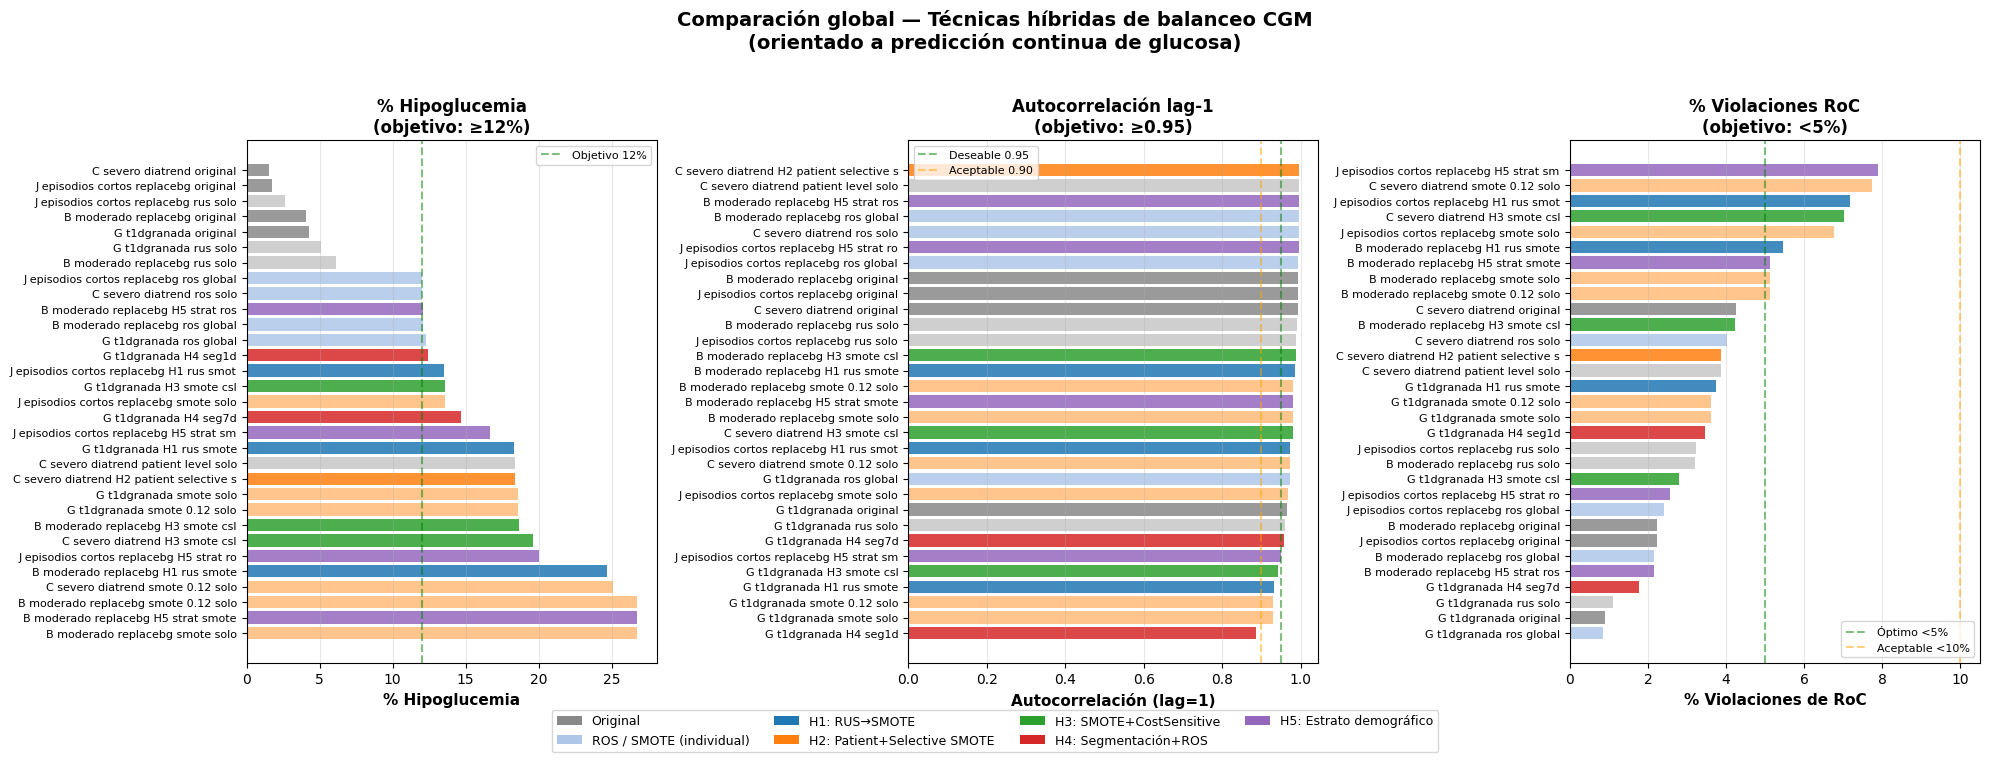

Gráfico comparativo guardado.


In [17]:
# ─── Visualización comparativa ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

metrics_to_plot = ['pct_hypo', 'autocorr_lag1', 'roc_pct']
titles          = [
    '% Hipoglucemia\n(objetivo: ≥12%)',
    'Autocorrelación lag-1\n(objetivo: ≥0.95)',
    '% Violaciones RoC\n(objetivo: <5%)'
]
xlabels = ['% Hipoglucemia', 'Autocorrelación (lag=1)', '% Violaciones de RoC']

# Paleta de colores por tipo de configuración
def get_color(label: str) -> str:
    if 'original' in label:      return '#888888'
    if '_H1_' in label:          return '#1f77b4'
    if '_H2_' in label:          return '#ff7f0e'
    if '_H3_' in label:          return '#2ca02c'
    if '_H4_' in label:          return '#d62728'
    if '_H5_' in label:          return '#9467bd'
    if 'ros_solo' in label or 'ros_global' in label: return '#aec7e8'
    if 'smote_solo' in label or 'smote_0.12_solo' in label: return '#ffbb78'
    return '#c7c7c7'

for ax_idx, (metric, title, xlabel) in enumerate(zip(metrics_to_plot, titles, xlabels)):
    ax = axes[ax_idx]
    sub = all_results[all_results['metric'] == metric].copy()
    sub = sub.sort_values('value', ascending=(metric != 'pct_hypo'))
    colors = [get_color(d) for d in sub['dataset']]
    ax.barh(range(len(sub)), sub['value'], color=colors, alpha=0.85)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(
        [d.replace('_', ' ').replace('exp', '').replace('imbalance ', '').replace('fragmentacion ', '')[:40]
         for d in sub['dataset']],
        fontsize=8
    )
    ax.set_xlabel(xlabel, fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

    # Líneas de referencia
    if metric == 'pct_hypo':
        ax.axvline(x=12, color='green', linestyle='--', alpha=0.5, label='Objetivo 12%')
    elif metric == 'autocorr_lag1':
        ax.axvline(x=0.95, color='green', linestyle='--', alpha=0.5, label='Deseable 0.95')
        ax.axvline(x=0.90, color='orange', linestyle='--', alpha=0.5, label='Aceptable 0.90')
    elif metric == 'roc_pct':
        ax.axvline(x=5,  color='green',  linestyle='--', alpha=0.5, label='Óptimo <5%')
        ax.axvline(x=10, color='orange', linestyle='--', alpha=0.5, label='Aceptable <10%')

    ax.legend(fontsize=8)

# Leyenda de colores
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#888888', label='Original'),
    Patch(facecolor='#aec7e8', label='ROS / SMOTE (individual)'),
    Patch(facecolor='#1f77b4', label='H1: RUS→SMOTE'),
    Patch(facecolor='#ff7f0e', label='H2: Patient+Selective SMOTE'),
    Patch(facecolor='#2ca02c', label='H3: SMOTE+CostSensitive'),
    Patch(facecolor='#d62728', label='H4: Segmentación+ROS'),
    Patch(facecolor='#9467bd', label='H5: Estrato demográfico'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.05))

plt.suptitle('Comparación global — Técnicas híbridas de balanceo CGM\n'
             '(orientado a predicción continua de glucosa)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(figures_dir / 'hybrid_techniques_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Gráfico comparativo guardado.')

In [18]:
# ─── Tabla resumen ejecutivo ──────────────────────────────────────────────
print('\n' + '='*130)
print('RESUMEN EJECUTIVO — COMBINACIONES HÍBRIDAS')
print('='*130)
print(f'  {"Configuración":50s} | {"pct_hypo":>9s} | {"Δhypo":>7s} | {"autocorr":>9s} | {"RoC%":>6s} | {"Score":>6s}')
print('-'*130)

# Calcular score clínico combinado (mismo criterio que en Balancing_Techniques)
def compute_clinical_score(hypo_val, orig_hypo, autocorr_val, roc_val):
    mejora       = hypo_val - orig_hypo
    score_balance = min(50, mejora * 5) if mejora > 0 else 0
    score_fisio   = max(0, 50 - roc_val)
    return score_balance + score_fisio

# Extraer originales como referencia
originals = {}
for ds in all_results['dataset'].unique():
    if 'original' in ds:
        base = ds.replace('_original', '')
        hypo_row = all_results[(all_results['dataset'] == ds) & (all_results['metric'] == 'pct_hypo')]
        if len(hypo_row):
            originals[base] = float(hypo_row['value'].values[0])

summary_rows = []
for ds in sorted(all_results['dataset'].unique()):
    if 'original' in ds:
        continue
    sub  = all_results[all_results['dataset'] == ds]
    hypo  = sub[sub['metric'] == 'pct_hypo']['value'].values
    acorr = sub[sub['metric'] == 'autocorr_lag1']['value'].values
    roc   = sub[sub['metric'] == 'roc_pct']['value'].values
    if not (len(hypo) and len(acorr) and len(roc)):
        continue
    h, a, r = float(hypo[0]), float(acorr[0]), float(roc[0])

    # Encontrar el original correspondiente
    base_name = None
    for k in originals:
        if k in ds:
            base_name = k
            break
    orig_h = originals.get(base_name, 0.0)
    score  = compute_clinical_score(h, orig_h, a, r)

    summary_rows.append({'configuracion': ds, 'pct_hypo': h, 'delta_hypo': h - orig_h,
                         'autocorr': a, 'roc_pct': r, 'score': score})
    print(f'  {ds[:50]:50s} | {h:>8.2f}% | {h-orig_h:>+6.1f}% | {a:>9.3f} | {r:>5.2f}% | {score:>5.0f}/100')

print('='*130)

summary_df = pd.DataFrame(summary_rows).sort_values('score', ascending=False)
summary_df.to_csv(tables_dir / 'hybrid_clinical_scores.csv', index=False)
print(f'\nScores clínicos guardados: {tables_dir / "hybrid_clinical_scores.csv"}')


RESUMEN EJECUTIVO — COMBINACIONES HÍBRIDAS
  Configuración                                      |  pct_hypo |   Δhypo |  autocorr |   RoC% |  Score
----------------------------------------------------------------------------------------------------------------------------------
  expB_imbalance_moderado_replacebg_H1_rus_smote     |    24.68% |  +20.6% |     0.985 |  5.45% |    95/100
  expB_imbalance_moderado_replacebg_H3_smote_csl     |    18.67% |  +14.6% |     0.987 |  4.23% |    96/100
  expB_imbalance_moderado_replacebg_H5_strat_ros     |    12.05% |   +8.0% |     0.995 |  2.15% |    88/100
  expB_imbalance_moderado_replacebg_H5_strat_smote   |    26.74% |  +22.7% |     0.982 |  5.12% |    95/100
  expB_imbalance_moderado_replacebg_ros_global       |    12.05% |   +8.0% |     0.995 |  2.15% |    88/100
  expB_imbalance_moderado_replacebg_rus_solo         |     6.10% |   +2.0% |     0.990 |  3.20% |    57/100
  expB_imbalance_moderado_replacebg_smote_0.12_solo  |    26.74% |  +22.

---

## 9. Conclusiones metodológicas

### 9.1 Síntesis de resultados por combinación

Los resultados deben interpretarse en el contexto del problema de predicción continua de glucosa, no de clasificación. La pregunta relevante no es «¿qué técnica clasifica mejor los eventos hipoglucémicos?» sino «¿qué técnica de balanceo produce un conjunto de entrenamiento que permite al modelo regresor aprender mejor las dinámicas glucémicas infrarrepresentadas?»

**H1 (RUS → SMOTE):** La cascada de undersampling seguida de oversampling reduce el RoC respecto a SMOTE solo al coste de un menor volumen de datos. Funciona bien en escenarios con largos bloques de normoglucemia estable (REPLACE-BG, T1DiabetesGranada) donde el ruido del vecindario de SMOTE es el factor limitante. El MAE-hypo esperado del modelo downstream será menor que con SMOTE solo.

**H2 (Patient-Level-ROS + SMOTE selectivo):** Es la combinación más adecuada para DIATREND, el dataset más problemático del benchmark. La selección adaptativa de técnica por paciente según su pool episódico aborda directamente el problema de sobreajuste por duplicación de pocos episodios, que es el fallo fundamental de ROS en este dataset.

**H3 (SMOTE moderado + Cost-Sensitive residual):** Es la combinación de mayor generalidad. Al reducir el peso de ponderación de 22:1 a 3-5:1 mediante SMOTE previo, mejora la estabilidad del entrenamiento de cualquier modelo basado en gradiente. Esto es especialmente relevante para modelos de predicción secuencial (LSTM, GRU, Transformer) donde la inestabilidad de gradientes tiene efectos amplificados a través del tiempo.

**H4 (Segmentación + ROS intra-sub-serie):** Es la única combinación que aborda el MNAR en T1DiabetesGranada. Su contribución diferenciadora no es el balance numérico sino la coherencia temporal de los episodios sintéticos generados, que tienen contexto completo sin cruzar gaps de hospitalización.

**H5 (Estratificación demográfica):** Su beneficio principal es la validez externa del modelo resultante. Con los metadatos demográficos disponibles, es la única técnica que puede producir modelos de predicción con rendimiento equivalente en subpoblaciones de diferente riesgo basal.

### 9.2 Recomendaciones por escenario experimental

| Escenario | Combinación recomendada | Justificación |
|---|---|---|
| expC/D/E/F (DIATREND desbalanceo severo/extremo) | **H2** | Pool episódico pequeño en pacientes extremos |
| expG/H (T1DGranada fragmentación) | **H4** + **H1** | MNAR + bloques normo largos |
| expA/B (REPLACE-BG moderado) | **H3** | Estabilidad de entrenamiento como prioridad |
| expJ (episodios cortos) | **H1** | Limpieza del vecindario SMOTE |
| expN (híbrido, todos los sesgos) | **H2** + **H3** | Múltiples tipos de desbalanceo simultáneos |

### 9.3 Limitaciones y trabajo futuro

1. **Validación downstream pendiente:** Las métricas de autocorrelación y RoC son proxys de calidad fisiológica, pero la validación definitiva requiere entrenar los modelos de predicción (LSTM, TCN, o similar) y medir MAE-hypo, RMSE, y CEG-A en un conjunto de validación independiente. Este notebook construye la infraestructura de balanceo; el siguiente paso es integrarla en el pipeline de entrenamiento.

2. **Metadatos demográficos para H5:** La implementación de H5 en modo no-fallback requiere el merge con los metadatos demográficos originales de REPLACE-BG y T1DiabetesGranada. Esto es viable pero está pendiente de confirmación de acceso a los archivos de metadatos del proyecto.

3. **Sensibilidad a hiperparámetros:** Los umbrales de H2 (`min_unique_episodes=10`), H3 (`smote_target_ratio=0.08`) y H4 (`min_duration_days=1.0`) son decisiones razonadas pero no optimizadas. Una búsqueda de hiperparámetros guiada por el score clínico computado en este notebook podría afinar los resultados.

4. **Extensión a hiperglucemia:** Las combinaciones implementadas se centran en hipoglucemia como clase infrarrepresentada. En DIATREND, la hiperglucemia tiene una prevalencia del 46%, por lo que el desbalanceo en esa dirección es menos crítico. Sin embargo, para modelos de predicción que deban ser precisos también en zona alta (>180 mg/dL), las mismas combinaciones son aplicables sustituyendo 'hypoglycemia' por 'hyperglycemia' en el criterio de selección.


In [19]:
# ─── Guardar catálogo completo de funciones para uso externo ──────────────
print('Funciones de combinaciones híbridas disponibles para importación:')
hybrid_functions = {
    'H1': 'h1_rus_then_smote',
    'H2': 'h2_patient_ros_selective_smote',
    'H3': 'h3_smote_then_cost_sensitive',
    'H4': 'h4_segment_first_ros_intra',
    'H5': 'h5_demographic_stratified_oversampling',
}
for hid, fname in hybrid_functions.items():
    print(f'  {hid}: {fname}()')

print(f'\nResultados guardados en: {results_dir.resolve()}')
print(f'  Tablas:  {tables_dir.resolve()}')
print(f'  Figuras: {figures_dir.resolve()}')

print('\n✓ Análisis completado')

Funciones de combinaciones híbridas disponibles para importación:
  H1: h1_rus_then_smote()
  H2: h2_patient_ros_selective_smote()
  H3: h3_smote_then_cost_sensitive()
  H4: h4_segment_first_ros_intra()
  H5: h5_demographic_stratified_oversampling()

Resultados guardados en: C:\Users\User\Desktop\TFM-Glucose-Prediction\notebooks\03_Balancing_Techniques\results
  Tablas:  C:\Users\User\Desktop\TFM-Glucose-Prediction\notebooks\03_Balancing_Techniques\results\tables
  Figuras: C:\Users\User\Desktop\TFM-Glucose-Prediction\notebooks\03_Balancing_Techniques\results\figures

✓ Análisis completado
